In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from math import sqrt
import time
import re
from scipy import signal
import ipywidgets as widgets
from src.analisi.tools import *

In [2]:
%matplotlib widget
plt.close('all')

In [3]:
# selettore cartella
folder_selector = widgets.Dropdown( 
    options=sorted([f for f in os.listdir(base_img_folder) if os.path.isdir(os.path.join(base_img_folder, f))], reverse=True),
    description='Sessione:',
    style={'description_width': 'initial'}
)

display(folder_selector)

Dropdown(description='Sessione:', options=('percolazione', 'lampadina_test_final', 'lampadina3_test', 'lampadi…

In [4]:
#raccolgiamo le immagini per calcolare le intensità medie 

images, image_timestamps = load_images_from_folder(os.path.join(base_img_folder, folder_selector.value, 'images'))
images, image_timestamps = sort_images_and_timestamps(images, image_timestamps)

image_seconds = [time.mktime(time.strptime(ts, FORMATO_COMUNE)) for ts in image_timestamps]
image_seconds = np.array(image_seconds)

image_trel = image_seconds - image_seconds[0]

In [5]:
bilancia_timestamps, bilancia_thicknesses, bilancia_rates = load_bilancia_data(os.path.join(base_img_folder, folder_selector.value, "data", 'points.txt'))
bilancia_timestamps = np.array(bilancia_timestamps)
bilancia_trel = bilancia_timestamps - bilancia_timestamps[0]

In [6]:
m, q = np.polyfit(bilancia_trel, bilancia_thicknesses, 1)
spessori_proiettati = m * image_trel + q

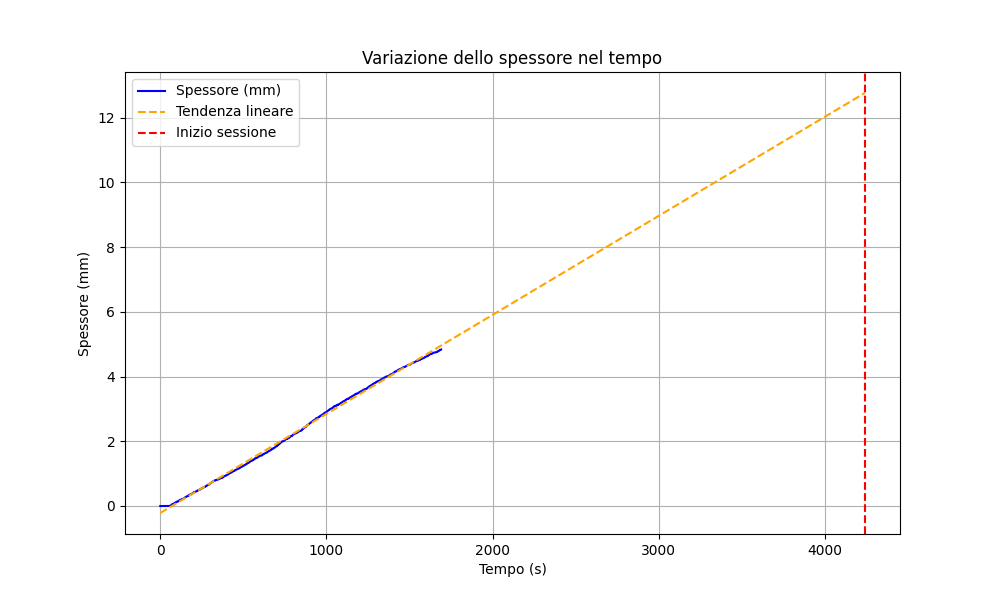

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(bilancia_trel, bilancia_thicknesses, label='Spessore (mm)', color='blue')

plt.plot(image_trel, spessori_proiettati, label='Tendenza lineare', color='orange', linestyle='--')

plt.xlabel('Tempo (s)')
plt.ylabel('Spessore (mm)')
plt.axvline(x=image_trel[-1], color='red', linestyle='--', label='Inizio sessione')
plt.title('Variazione dello spessore nel tempo')
plt.legend()
plt.grid(True)
plt.show()

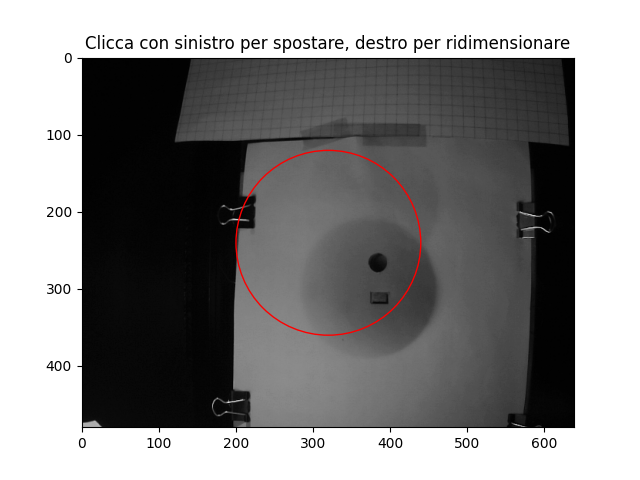

In [8]:
roi_select = RoiSelectorWidget(images[-1])

In [9]:
print(roi_select.roi)

((320, 240), 120)


In [10]:
roi_center, roi_radius = roi_select.roi

reference_image = np.mean(images[:10], axis=0) if images else None
roi_images = extract_roi_from_images(images, roi_center, roi_radius)
reference_image_roi = extract_roi_from_images([reference_image], roi_center, roi_radius)[0]
difference_images = compute_difference_from_reference(roi_images, reference_image_roi)

In [11]:
window_size = 10

images_smooth = moving_average_images(difference_images, window_size)
mean_intensities = np.mean(images_smooth, axis=(1, 2))
#[np.mean(img) for img in images_smooth]

fitted_thicknesses = mean_intensities       #slope * np.array(mean_intensities) + intercept

In [12]:

m, q = np.polyfit(mean_intensities, spessori_proiettati, 1)
fitted_thicknesses = m * mean_intensities + q

In [13]:
print(np.max(fitted_thicknesses), np.min(fitted_thicknesses))

14.850894478816938 -13.131230444837557


In [14]:
elettrometro_dir = os.path.join(base_img_folder, folder_selector.value, 'data/points_keithley.txt')

In [15]:
keithley_currents, keithley_timestamps, keithley_ranges = load_keithley_data(elettrometro_dir)

keithley_currents = np.array(keithley_currents)
keithley_timestamps = np.array(keithley_timestamps)
keithley_trel = keithley_timestamps - keithley_timestamps[0]

print(max(keithley_trel))

4187.232023


In [16]:
auto_range_indices = np.array([i for i, r in enumerate(keithley_ranges) if r == -1])
plus2_inds = auto_range_indices - 1
plus1_inds = auto_range_indices - 2


elettrometro_series = {
    "auto": (keithley_trel[auto_range_indices], keithley_currents[auto_range_indices]),
    "+2": (keithley_trel[plus2_inds], keithley_currents[plus2_inds]),
    "+1": (keithley_trel[plus1_inds], keithley_currents[plus1_inds])
}


In [17]:
# interpolazione correnti sui timestamp della bilancia
elettrometro_series_interpolated = {}

start_time = 0
#finish_time = 2100 #lo attivo se voglio cercare lo spessore di percolazione perché il fit va fatto solo nei pressi dello spessore critico


for key, (t_rel, currents) in elettrometro_series.items():

    # select only data points where t >= start_time

    mask_elettrometro = (t_rel >= start_time) #& (t_rel <= finish_time)
    mask_camera = (image_trel >= start_time) #& (image_trel <= finish_time)

    t_rel_cut = t_rel[mask_elettrometro]
    currents_cut = currents[mask_elettrometro]

    image_trel_masked = image_trel[mask_camera]
    
    interpolated_currents = np.interp(image_trel_masked, t_rel_cut, currents_cut)
    
    interpolated_res = calculate_resistance(np.array(interpolated_currents), 0.5)
    
    elettrometro_series_interpolated[key] = (image_trel_masked, interpolated_currents)
    
    

    print(len(image_trel_masked), len(interpolated_currents), len(interpolated_res))


4240 4240 4240
4240 4240 4240
4240 4240 4240


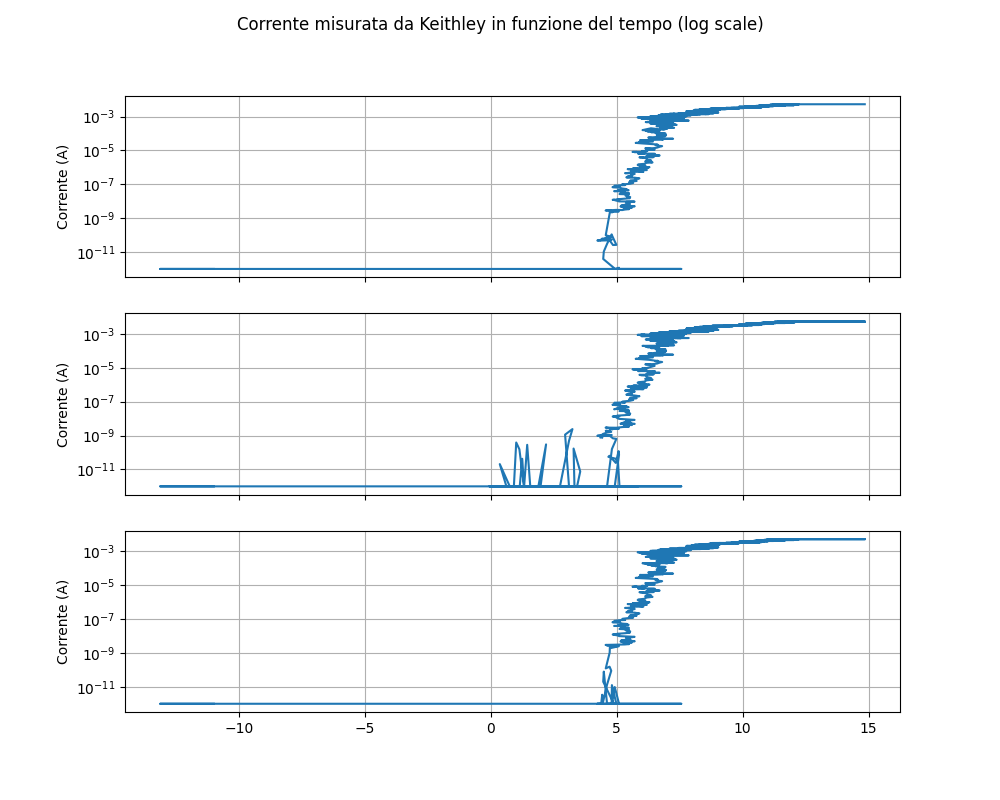

In [18]:
#plt.figure(figsize=(10, 6))

fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

fig.suptitle('Corrente misurata da Keithley in funzione del tempo (log scale)')


for ax, (key, val) in zip(axes, elettrometro_series_interpolated.items()):

    t, curr = val

    less_than_zero_mask = curr < 0
    curr[less_than_zero_mask] = 0

    reasonableness_mask = (curr > 1e-12) & (curr < 1e2)
    curr[~reasonableness_mask] = 0

    zero_mask = curr == 0
    curr[zero_mask] = 1e-12

    ax.plot(fitted_thicknesses[mask_camera], curr, label=f'Keithley {key}', marker='', linestyle='-', markersize=4)

    #ax.plot(fitted_thicknesses, interpolated_currents, label=f'Keithley {key}', marker='', linestyle='-', markersize=4)
    ax.set_yscale('log')
    ax.set_ylabel('Corrente (A)')
    #ax.legend()
    ax.grid(True)
    #ax.set_ylim(np.min(curr), np.max(curr))

plt.show()

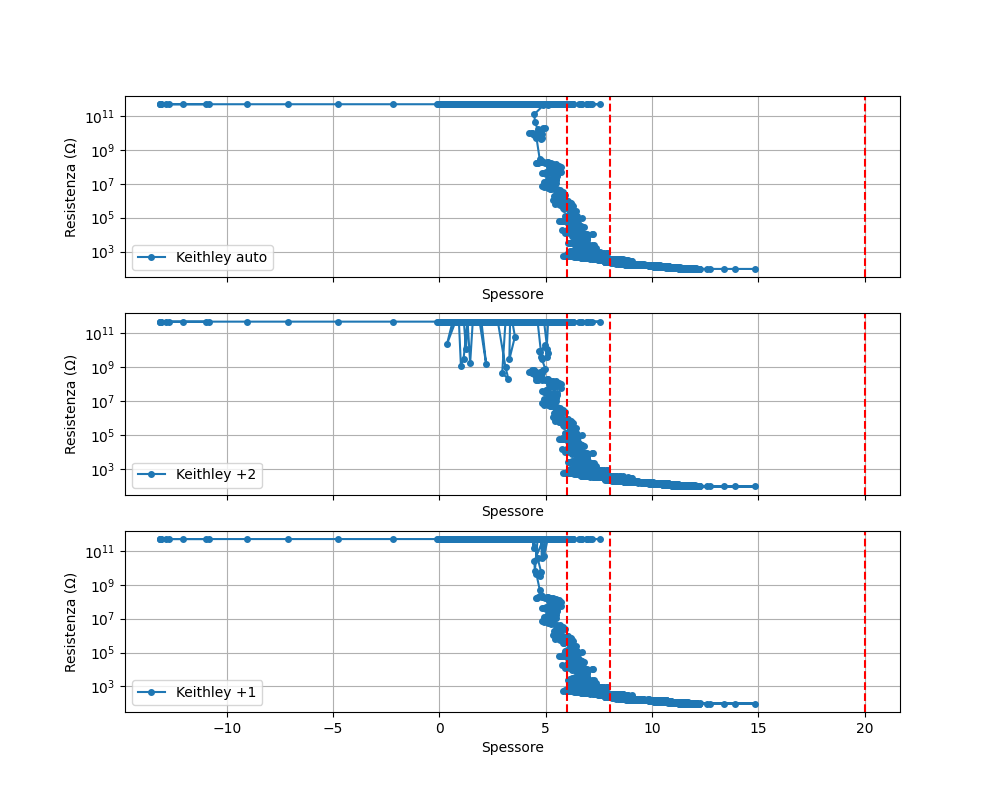

In [19]:
#plt.figure(figsize=(10, 6))
fig, axes = plt.subplots(3, 1, sharex=True, figsize=(10, 8))

# disegna la curva percolativa con le resistenze in funzione dei fitted_thicknesses
# le resistenze dipendono dalla serie di corrente identificata dal key del range
# gli spessori son fittati e sono indipendenti dalla serie di corrente

target_xs = [6, 8, 20]


for ax, (key, val) in zip(axes, elettrometro_series_interpolated.items()):
    ax.plot(fitted_thicknesses[mask_camera], 0.5/val[1], label=f'Keithley {key}', marker='o', linestyle='-', markersize=4)
    ax.set_ylabel('Resistenza (Ω)')
    ax.set_xlabel('Spessore')
    [ax.axvline(x=i, linestyle='--', color='red') for i in target_xs]
    ax.set_yscale('log')
    ax.legend()
    ax.grid(True)


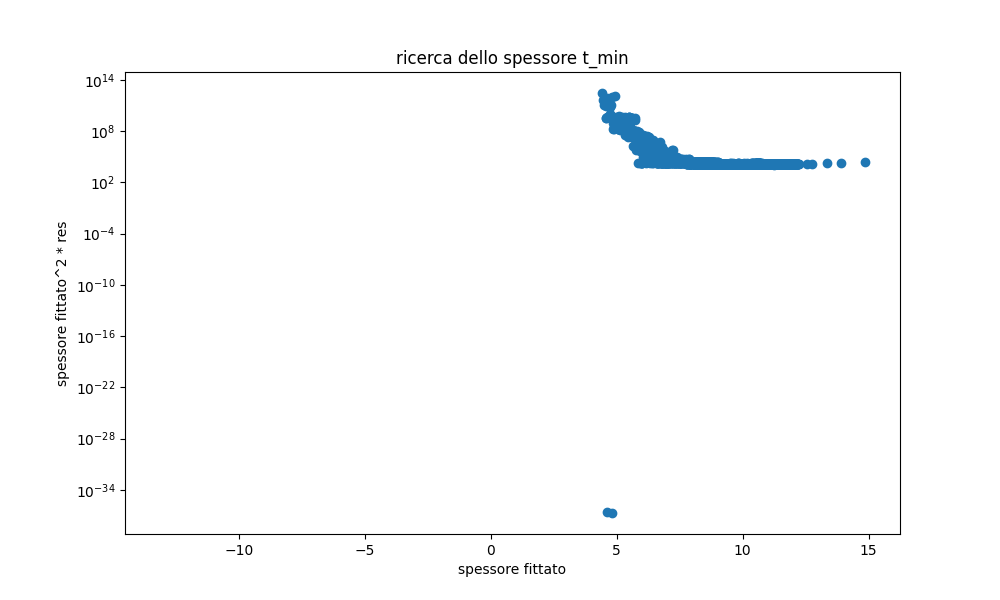

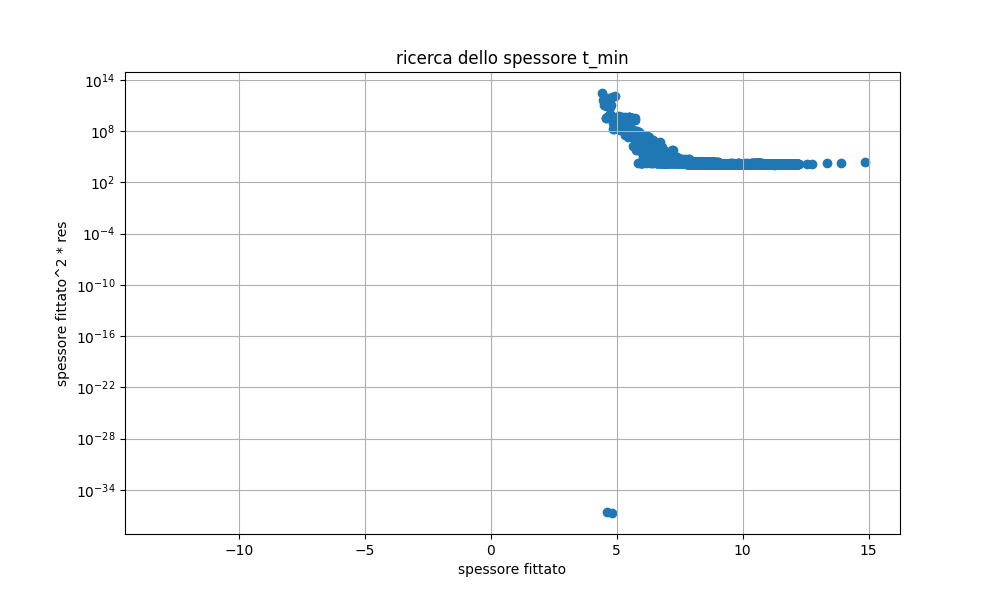

In [20]:
# ricerca dello spessore t_min, passaggio da percolativo a ohmico (il campione ha formato uno strato continuo oltre la percolazione)

Rt2 = [r * (t**2) for r, t in zip(interpolated_res, fitted_thicknesses[mask_camera])]

plt.figure(figsize=(10, 6))
plt.scatter(fitted_thicknesses[mask_camera], Rt2)
plt.xlabel('spessore fittato')
plt.ylabel('spessore fittato^2 * res')
plt.yscale('log')

plt.title('ricerca dello spessore t_min')
plt.show()
plt.grid(True)
plt.show()

/home/luca/Desktop/Code/lab_materia_2/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1317: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
/home/luca/Desktop/Code/lab_materia_2/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
/home/luca/Desktop/Code/lab_materia_2/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
/home/luca/Desktop/Code/lab_materia_2/.venv/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:1328: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] \


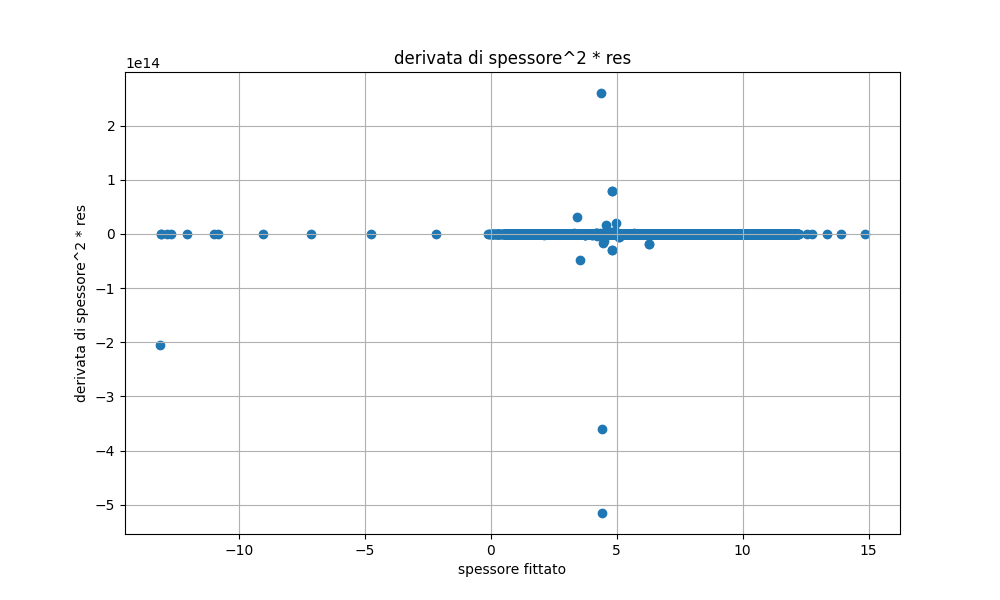

In [21]:
deltax = []
deltat = []

Rt2 = [r * (t**2) for r, t in zip(interpolated_res, fitted_thicknesses[mask_camera])]

derivata = np.gradient(Rt2, fitted_thicknesses[mask_camera])

plt.figure(figsize=(10, 6))
plt.scatter(fitted_thicknesses[mask_camera], derivata)
plt.xlabel('spessore fittato')
plt.ylabel('derivata di spessore^2 * res')
plt.title('derivata di spessore^2 * res')
#plt.yscale('log')
plt.grid(True)
plt.show()

/tmp/ipykernel_23013/3857200721.py:6: RuntimeWarning: invalid value encountered in log
  logG = np.log(1/interpolated_res)


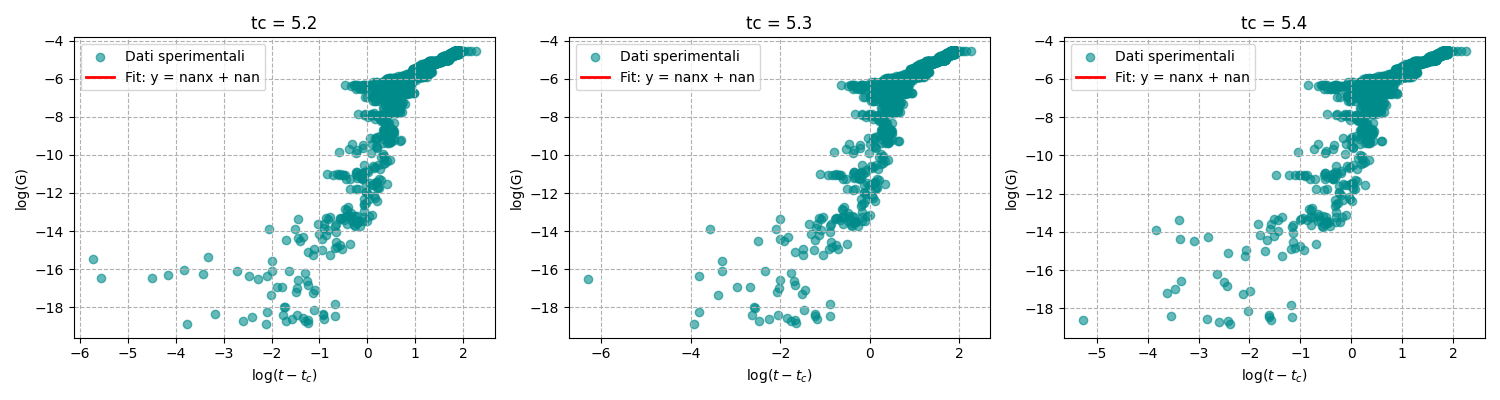

In [22]:
# ricerca dello spessore di percolazione t_c (spessore critico)

step = 0.1
tc= np.arange(5.2, 5.4+step, step)

logG = np.log(1/interpolated_res)



fig, ax = plt.subplots(1, len(tc), figsize=(15, 4))



for j, t in enumerate(tc):
    diff = fitted_thicknesses[mask_camera] - t
    valid_mask = diff > 0
    log_t_tc = np.log(diff[valid_mask])
    logG_filtered = logG[valid_mask]
    m, q = np.polyfit(log_t_tc, logG_filtered, 1)
    y_fit = m * log_t_tc + q
    ax[j].scatter(log_t_tc, logG_filtered, alpha=0.6, label="Dati sperimentali", color="darkcyan")
    ax[j].plot(log_t_tc, y_fit, color="red", lw=2, label=f"Fit: y = {m:.2f}x + {q:.2f}")
    ax[j].set_title(f'tc = {tc[j]:.1f}')
    ax[j].set_xlabel("log($t - t_c$)")
    ax[j].set_ylabel('log(G)')
    ax[j].grid(True, which="both", ls="--")
    ax[j].legend()
plt.tight_layout()
plt.show()

 

/tmp/ipykernel_23013/63733317.py:7: RuntimeWarning: invalid value encountered in log
  logG = np.log(1/interpolated_res)


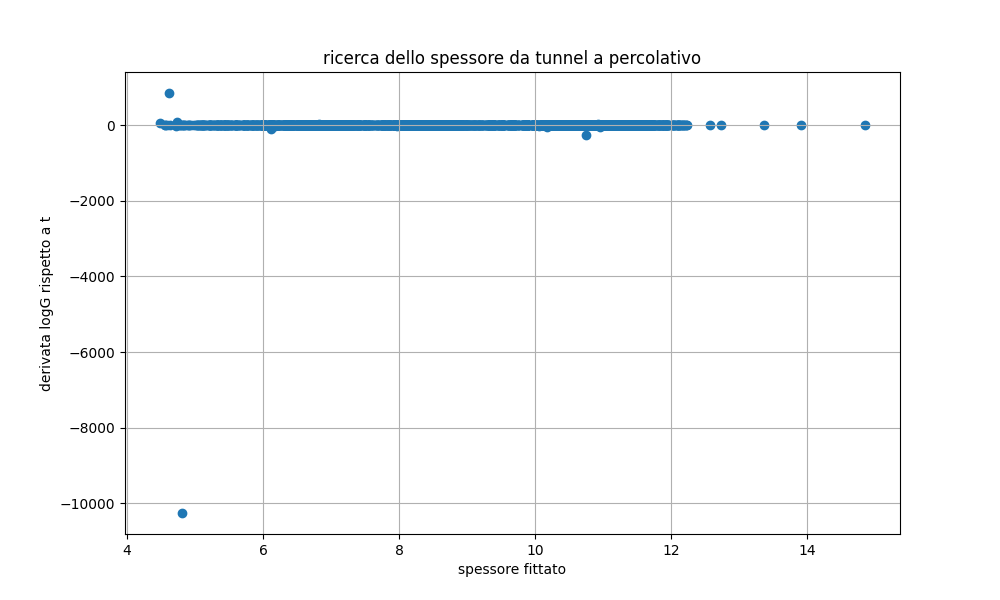

In [23]:
# ricerca dello spessore da tunnel a percolativo, è il massimo della derivata di logG rispetto a t


deltaG = []
deltat = []

logG = np.log(1/interpolated_res)

for i in range(1, len(logG)):
    deltaG.append(logG[i] - logG[i-1])
    deltat.append(fitted_thicknesses[mask_camera][i] - fitted_thicknesses[mask_camera][i-1])
    
derivata = np.array(deltaG) / np.array(deltat)


plt.figure(figsize=(10, 6))
plt.scatter(fitted_thicknesses[mask_camera][1:], derivata)
plt.xlabel('spessore fittato')
plt.ylabel('derivata logG rispetto a t')
plt.title('ricerca dello spessore da tunnel a percolativo')
plt.grid(True)
plt.show()